# What is the First Day of the Week?

Whether the Gregorian calendar shows Sunday or Monday as the first day of the week depends on where you live.

Do more countries start the week on Sunday or Monday? What about people? What about by continent?

The file `first-day-of-week.csv` shows the first day of the week for each territory. The file `population.csv` shows the population in the year 2020 for each territory in millions, and the file `four-regions.csv` specifies whether each territory is in asia, europe, africa, or the americas. 


In [1]:
# FOR GOOGLE COLAB ONLY.
# Uncomment and run the code below. A dialog will appear to upload files.
# Upload 'first-day-of-week.csv', 'population.csv', and 'four-regions.csv'.

# from google.colab import files
# uploaded = files.upload()

In [1]:
import pandas as pd
df = pd.read_csv('first-day-of-week.csv')
df.head()

,territory,alpha3,first_day,units,paper
0,Afghanistan,AFG,sat,metric,A4
1,Aland Islands,ALA,mon,metric,A4
2,Albania,ALB,mon,metric,A4
3,Algeria,DZA,sat,metric,A4
4,American Samoa,ASM,sun,metric,A4


In [2]:
pop = pd.read_csv('population.csv')
pop.head()

,alpha3,population
0,AFG,39.07
1,ALB,2.87
2,DZA,44.04
3,AND,0.08
4,AGO,33.45


In [4]:
regions = pd.read_csv('four-regions.csv')
regions.head()

,alpha3,four_regions
0,AUS,asia
1,BRN,asia
2,KHM,asia
3,CHN,asia
4,FJI,asia


### Project Ideas

- How many territories show Friday, Saturday, Sunday, and Monday as the `first_day` of the week?

- How many people start the week on Friday, Saturday, Sunday, and Monday?
	- Hint: This will involve a `merge`.

- Which of the `four_regions` predominantly start the week on Sunday? On Monday? Are there any regions that are more divided between Sunday and Monday?
	- Hint: This will also involve a `merge`.

To refer to a local variable (like your List_of_days) inside a query() expression, you must prefix it with the @ symbol

In [53]:
List_of_days = ['fri', 'sat', 'sun', 'mon']
F_S_S_M = df.query("first_day in @List_of_days")
count_fssm = F_S_S_M.count()
count_fssm

territory    257
alpha3       254
first_day    257
units        257
paper        257
dtype: int64

In [30]:
F_S_S_M.head()

,territory,alpha3,first_day,units,paper
0,Afghanistan,AFG,sat,metric,A4
1,Aland Islands,ALA,mon,metric,A4
2,Albania,ALB,mon,metric,A4
3,Algeria,DZA,sat,metric,A4
4,American Samoa,ASM,sun,metric,A4


In [58]:
F_S_S_M_pop = F_S_S_M.merge(pop, on='alpha3', how="left").dropna()
F_S_S_M_pop['population'].sum().astype(int)

np.int64(7876)

In [61]:
F_S_S_M_pop_regions = F_S_S_M_pop.merge(regions, on='alpha3', how='left')
F_S_S_M_pop_regions.head()

,territory,alpha3,first_day,units,paper,population,four_regions
0,Afghanistan,AFG,sat,metric,A4,39.07,asia
1,Albania,ALB,mon,metric,A4,2.87,europe
2,Algeria,DZA,sat,metric,A4,44.04,africa
3,Andorra,AND,mon,metric,A4,0.08,europe
4,Angola,AGO,mon,metric,A4,33.45,africa


In [91]:
inb = F_S_S_M_pop_regions.groupby('four_regions')['first_day'].value_counts()
inb


four_regions  first_day
africa        mon          43
              sun           6
              sat           5
americas      sun          20
              mon          15
asia          mon          27
              sun          21
              sat          10
              fri           1
europe        mon          46
              sun           2
Name: count, dtype: int64

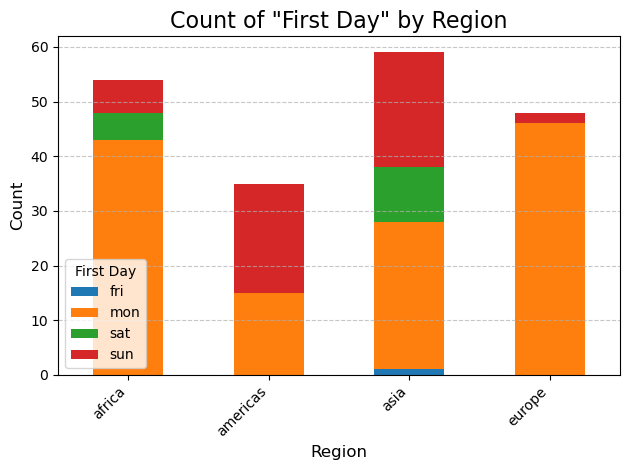

In [90]:
import matplotlib.pyplot as plt
inb.unstack().plot(kind='bar', stacked=True)

plt.title('Count of "First Day" by Region', fontsize=16)
plt.xlabel('Region', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45, ha="right") # Rotate x-axis labels for better readability
plt.legend(title='First Day')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout() # Adjusts plot to ensure everything fits without overlapping

# 5. Display the plot
plt.show()